# **Iterative policy evaluation - Stochastic policy (without gym library)**

---



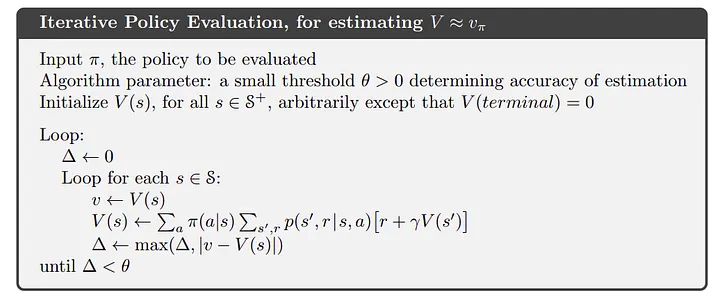

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# **Functions**

In [ ]:
def Environment(AllStates, State, Action, Goal):

  Row = State[0]
  Col = State[1]

  RowV = Action[0]
  ColV = Action[1]

  NewState = np.array([Row + RowV, Col + ColV])

  if np.any(np.all(AllStates == NewState, axis=1)):
    if np.all(Goal == NewState):
      Reward = 10
    else:
      Reward = -1
  else:
    Reward = -10
    NewState = np.array([Row, Col])


  if np.all(Goal == np.array([Row, Col])):
    Reward = 0
    NewState = np.array([Row, Col])


  return NewState, Reward


#################################################################################
def GenerateEnv(plane, AllStates, AllActions, PlaneSized, InitialStates, Vs, Goal):


  plane2 = plane.copy()

  plt.imshow(plane2)


  plane2[InitialStates[1], InitialStates[0]]= 0.75
  plt.imshow(plane2)


  while True:

    for i in range(plane2.size):

      StateDown = InitialStates + AllActions[0]
      if np.any(np.all(StateDown == AllStates, axis=1)):
        IndexDown = np.where(np.all(StateDown == AllStates, axis=1))[0]
        ValueDown = Vs[IndexDown]
      else:
        ValueDown = [-1000]


      StateUp = InitialStates + AllActions[1]
      if np.any(np.all(StateUp == AllStates, axis=1)):
        IndexUp = np.where(np.all(StateUp == AllStates, axis=1))[0]
        ValueUp = Vs[IndexUp]
      else:
        ValueUp = [-1000]


      StateRight = InitialStates + AllActions[2]
      if np.any(np.all(StateRight == AllStates, axis=1)):
        IndexRight = np.where(np.all(StateRight == AllStates, axis=1))[0]
        ValueRight = Vs[IndexRight]
      else:
        ValueRight = [-1000]


      StateLeft = InitialStates + AllActions[3]
      if np.any(np.all(StateLeft == AllStates, axis=1)):
        IndexLeft = np.where(np.all(StateLeft == AllStates, axis=1))[0]
        ValueLeft = Vs[IndexLeft]
      else:
        ValueLeft = [-1000]

      NextDirection = np.argmin(np.abs([float(ValueDown[0]), float(ValueUp[0]), float(ValueRight[0]), float(ValueLeft[0])]))


      InitialStatesNext = InitialStates + AllActions[NextDirection]
      InitialStates = InitialStatesNext

      plane2[InitialStatesNext[0], InitialStatesNext[1]]= 0.75
      plt.imshow(plane2)


    break


  for i in range(Vs.size):
    plt.text(AllStates[i][1], AllStates[i][0], round(Vs[i], 1), fontsize=6, color='Black', ha='center', va='center')

  plt.title("Plane Map")
  plt.xticks(range(PlaneSized))
  plt.yticks(range(PlaneSized))
  plt.show()



# **Create the environment with code (without gym library)**
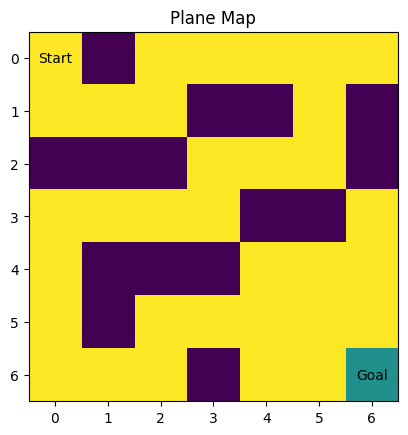

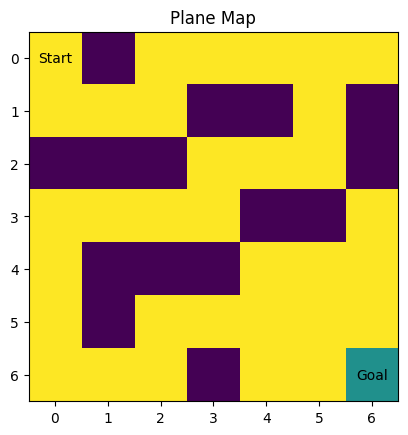

In [ ]:
PlaneSized = 7
OneStates = []
Gamma = 0.99
InitialStates = np.array([0, 0])

Plane = np.ones((PlaneSized, PlaneSized)) # 1 means free and 0 means barrier
barriers = [
    (0, 1),
    (1, 3), (1, 4), (1, 6),
    (2, 0), (2, 1), (2, 2), (2, 6),
    (3, 4), (3, 5),
    (4, 1), (4, 2), (4, 3),
    (5, 1),
    (6, 3)
]
Goal = np.array([PlaneSized-1, PlaneSized-1])
for r, c in barriers:
    Plane[r, c] = 0

for i in range(PlaneSized):
  for j in range(PlaneSized):
    if Plane[i, j] == 1:
      OneStates.append([i, j])


AllActions = np.array([[1, 0], [-1, 0], [0, 1], [0, -1]]) # [1, 0]: Down_0, [-1, 0]: Up_1, [0, 1]: Right_2, [0, -1]: Left_3
AllStates = np.array(OneStates)

Plane[PlaneSized-1, PlaneSized-1] = 0.5

plt.imshow(Plane)
plt.text(PlaneSized-1, PlaneSized-1, 'Goal', fontsize=10, color='Black', ha='center', va='center')
plt.text(0, 0, 'Start', fontsize=10, color='Black', ha='center', va='center')
plt.title("Plane Map")
plt.xticks(range(PlaneSized))
plt.yticks(range(PlaneSized))
plt.show()

# **Policy evaluation**

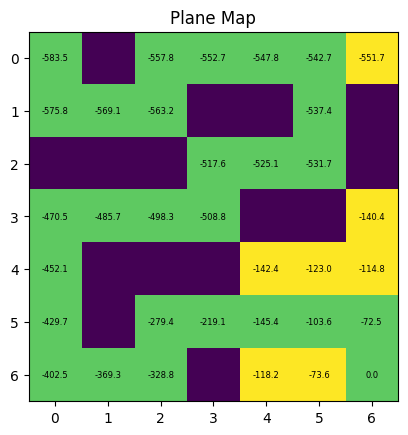

In [ ]:
Vs = np.zeros(AllStates.shape[0])
Theta = 1e-6

while True:

  Vs_old = Vs.copy()

  for i in range(Vs.size):

    ActionRewardDown = Environment(AllStates, AllStates[i], AllActions[0], Goal)
    IndexDown = np.where(np.all(AllStates == ActionRewardDown[0], axis=1))

    ActionRewardUp = Environment(AllStates, AllStates[i], AllActions[1], Goal)
    IndexUp = np.where(np.all(AllStates == ActionRewardUp[0], axis=1))

    ActionRewardRight = Environment(AllStates, AllStates[i], AllActions[2], Goal)
    IndexRight = np.where(np.all(AllStates == ActionRewardRight[0], axis=1))

    ActionRewardLeft = Environment(AllStates, AllStates[i], AllActions[3], Goal)
    IndexLeft = np.where(np.all(AllStates == ActionRewardLeft[0], axis=1))

    # Stochastic policy
    Vs[i] = 0.25 *  (ActionRewardDown[1] + Gamma * Vs[IndexDown][0]
                      + ActionRewardUp[1] + Gamma * Vs[IndexUp][0]
                      + ActionRewardRight[1] + Gamma * Vs[IndexRight][0]
                      + ActionRewardLeft[1] + Gamma * Vs[IndexLeft][0]
                    )


  if Theta >= np.linalg.norm(Vs - Vs_old, ord=2):
    break


GenerateEnv(Plane, AllStates, AllActions, PlaneSized, InitialStates, Vs, Goal)

